<a href="https://colab.research.google.com/github/havvy001/ira-sync-server/blob/main/Africa%20green%20parks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas osmnx networkx matplotlib folium branca shapely pycountry pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 46.6 MB/s eta 0:00:00


In [ ]:
import pycountry
import pandas as pd

# African country codes (ISO alpha-2) – manually verified set
africa_alpha2 = {
    'DZ', 'AO', 'BJ', 'BW', 'BF', 'BI', 'CM', 'CV', 'CF', 'TD', 'KM', 'CG', 'CD', 'DJ', 'EG',
    'GQ', 'ER', 'SZ', 'ET', 'GA', 'GM', 'GH', 'GN', 'GW', 'CI', 'KE', 'LS', 'LR', 'LY', 'MG',
    'MW', 'ML', 'MR', 'MU', 'MA', 'MZ', 'NA', 'NE', 'NG', 'RW', 'ST', 'SN', 'SC', 'SL', 'SO',
    'ZA', 'SS', 'SD', 'TZ', 'TG', 'TN', 'UG', 'ZM', 'ZW', 'EH'  # Western Sahara (disputed)
}

# Capital names from a reliable source (we’ll use a small dictionary)
# You can also use the 'country-capitals' package, but this dict is accurate.
capital_dict = {
    'Algeria': 'Algiers', 'Angola': 'Luanda', 'Benin': 'Porto-Novo', 'Botswana': 'Gaborone',
    'Burkina Faso': 'Ouagadougou', 'Burundi': 'Gitega', 'Cabo Verde': 'Praia', 'Cameroon': 'Yaoundé',
    'Central African Republic': 'Bangui', 'Chad': "N'Djamena", 'Comoros': 'Moroni',
    'Congo': 'Brazzaville', 'DR Congo': 'Kinshasa', 'Djibouti': 'Djibouti', 'Egypt': 'Cairo',
    'Equatorial Guinea': 'Malabo', 'Eritrea': 'Asmara', 'Eswatini': 'Mbabane', 'Ethiopia': 'Addis Ababa',
    'Gabon': 'Libreville', 'Gambia': 'Banjul', 'Ghana': 'Accra', 'Guinea': 'Conakry',
    'Guinea-Bissau': 'Bissau', 'Ivory Coast': 'Yamoussoukro', 'Kenya': 'Nairobi',
    'Lesotho': 'Maseru', 'Liberia': 'Monrovia', 'Libya': 'Tripoli', 'Madagascar': 'Antananarivo',
    'Malawi': 'Lilongwe', 'Mali': 'Bamako', 'Mauritania': 'Nouakchott', 'Mauritius': 'Port Louis',
    'Morocco': 'Rabat', 'Mozambique': 'Maputo', 'Namibia': 'Windhoek', 'Niger': 'Niamey',
    'Nigeria': 'Abuja', 'Rwanda': 'Kigali', 'Sao Tome and Principe': 'São Tomé',
    'Senegal': 'Dakar', 'Seychelles': 'Victoria', 'Sierra Leone': 'Freetown', 'Somalia': 'Mogadishu',
    'South Africa': 'Pretoria', 'South Sudan': 'Juba', 'Sudan': 'Khartoum', 'Tanzania': 'Dodoma',
    'Togo': 'Lomé', 'Tunisia': 'Tunis', 'Uganda': 'Kampala', 'Zambia': 'Lusaka', 'Zimbabwe': 'Harare',
    'Western Sahara': 'El Aaiún'
}

# Build the list
capitals = []
for country in pycountry.countries:
    if country.alpha_2 in africa_alpha2:
        name = country.name
        # Special case for "Congo" vs "DR Congo"
        if name == 'Congo':
            name = 'Congo'
        elif name == 'Congo, The Democratic Republic of the':
            name = 'DR Congo'
        capital = capital_dict.get(name)
        if capital:
            capitals.append({'city': capital, 'country': name, 'lat': None, 'lon': None})
        else:
            print(f"Missing capital for: {name}")

# Convert to DataFrame
capitals_df = pd.DataFrame(capitals)
print(f"Total capitals: {len(capitals_df)}")
capitals_df.head()

Missing capital for: Côte d'Ivoire
Missing capital for: Tanzania, United Republic of
Total capitals: 53


,city,country,lat,lon
0,Luanda,Angola,None,None
1,Gitega,Burundi,None,None
2,Porto-Novo,Benin,None,None
3,Ouagadougou,Burkina Faso,None,None
4,Gaborone,Botswana,None,None


In [ ]:
import osmnx as ox
import geopandas as gpd
import networkx as nx
import random
from shapely.geometry import Point
from shapely.ops import unary_union
import numpy as np
import multiprocessing as mp
from functools import partial

# Define shortest_distance_to_parks outside analyze_city
def _shortest_distance_to_parks_helper(res_node, G, park_nodes):
    min_dist = float('inf')
    for park_node in park_nodes:
        try:
            dist = nx.shortest_path_length(G, res_node, park_node, weight='length')
            if dist < min_dist:
                min_dist = dist
        except nx.NetworkXNoPath:
            continue
    return min_dist if min_dist != float('inf') else None

def analyze_city(city_name, country_name=None, radius_m=1000, sample_size=100):
    """
    Analyze green space accessibility for a given city.

    Parameters:
    - city_name: string, name of the city (e.g., 'Nairobi')
    - country_name: optional string to disambiguate (e.g., 'Kenya')
    - radius_m: int, radius (meters) around city center for network and points
    - sample_size: int, number of residential points to generate

    Returns:
    - result_gdf: GeoDataFrame with residential points and distances
    - metadata: dict with status, n_parks, error_msg, etc.
    """
    metadata = {
        'city': city_name,
        'country': country_name,
        'success': False,
        'n_parks': 0,
        'n_res_points': 0,
        'error_msg': None
    }

    try:
        # 1. Get city center coordinates
        if country_name:
            query = f"{city_name}, {country_name}"
        else:
            query = city_name

        # Use geocode to get lat/lon
        location = ox.geocode(query)
        lat, lon = location[0], location[1]
        metadata['center_lat'] = lat
        metadata['center_lon'] = lon

        # 2. Download street network (walking)
        G = ox.graph_from_point((lat, lon), dist=radius_m, network_type='walk')
        if len(G.nodes) == 0:
            raise ValueError("No street network found")

        # 3. Download green spaces
        tags = {'leisure': ['park', 'garden', 'recreation_ground', 'nature_reserve']}
        green_spaces = ox.features_from_point((lat, lon), tags=tags, dist=5000)

        # Keep only polygons
        if green_spaces.empty:
            metadata['n_parks'] = 0
            metadata['error_msg'] = "No green spaces found in OSM"
            return None, metadata

        green_polygons = green_spaces[green_spaces.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])]
        if green_polygons.empty:
            metadata['n_parks'] = 0
            metadata['error_msg'] = "Found features but no polygons"
            return None, metadata

        metadata['n_parks'] = len(green_polygons)

        # 4. Generate random residential points inside area of interest
        # Use union of green spaces buffered by 1 km to define the zone
        green_proj = green_polygons.to_crs(epsg=3857)
        area_polygon = unary_union(green_proj.buffer(radius_m).geometry)
        bounds = area_polygon.bounds

        res_points = []
        while len(res_points) < sample_size:
            x = random.uniform(bounds[0], bounds[2])
            y = random.uniform(bounds[1], bounds[3])
            p = Point(x, y)
            if area_polygon.contains(p):
                res_points.append(p)

        if not res_points:
            raise ValueError("Could not generate any residential points")

        res_gdf = gpd.GeoDataFrame(geometry=res_points, crs="EPSG:3857")
        res_gdf = res_gdf.to_crs(epsg=4326)  # WGS84 for network nodes
        metadata['n_res_points'] = len(res_gdf)

        # 5. Get nearest network nodes for parks and residences
        park_centroids = green_polygons.to_crs(epsg=3857).geometry.centroid.to_crs(epsg=4326)

        # Parallel: compute nearest nodes for residences
        res_nodes = ox.distance.nearest_nodes(G, res_gdf.geometry.x, res_gdf.geometry.y)
        park_nodes = ox.distance.nearest_nodes(G, park_centroids.x, park_centroids.y)

        # 6. Compute shortest path distances (in meters) using parallel processing
        # Use functools.partial to pass G and park_nodes to the helper function
        # This creates a new callable that only requires res_node
        partial_shortest_distance = partial(_shortest_distance_to_parks_helper, G=G, park_nodes=park_nodes)

        with mp.Pool(processes=mp.cpu_count()) as pool:
            distances = pool.map(partial_shortest_distance, res_nodes)

        # Remove None (unreachable points) – assign a large distance
        distances = [d if d is not None else np.nan for d in distances]

        # 7. Add distances to GeoDataFrame
        res_gdf['green_space_distance_m'] = distances
        res_gdf['green_space_distance_km'] = res_gdf['green_space_distance_m'] / 1000.0

        metadata['success'] = True
        return res_gdf, metadata

    except Exception as e:
        metadata['error_msg'] = str(e)
        return None, metadata

In [ ]:
import time
from tqdm import tqdm  # optional, for progress bar

# List to store successful results and metadata
all_results = []     # each element: (city_name, gdf)
failed_cities = []   # each element: (city_name, error_msg)

# Optional: load existing progress if you need to resume
# results_df = pd.read_csv('green_access_results.csv') if file exists

for idx, row in tqdm(capitals_df.iterrows(), total=len(capitals_df), desc="Analyzing capitals"):
    city = row['city']
    country = row['country']
    print(f"\nProcessing: {city}, {country}")

    try:
        gdf, meta = analyze_city(city, country, radius_m=1000, sample_size=100)

        if meta['success'] and gdf is not None:
            # Save the GeoDataFrame to a file (optional)
            gdf.to_file(f"results/{city.replace(' ', '_')}_access.geojson", driver='GeoJSON')

            # Compute summary statistics for this city
            summary = {
                'city': city,
                'country': country,
                'mean_distance_km': gdf['green_space_distance_km'].mean(),
                'median_distance_km': gdf['green_space_distance_km'].median(),
                'pct_within_300m': (gdf['green_space_distance_km'] <= 0.3).mean() * 100,
                'pct_within_500m': (gdf['green_space_distance_km'] <= 0.5).mean() * 100,
                'pct_within_1km': (gdf['green_space_distance_km'] <= 1.0).mean() * 100,
                'pct_over_1km': (gdf['green_space_distance_km'] > 1.0).mean() * 100,
                'n_parks': meta['n_parks'],
                'n_res_points': meta['n_res_points']
            }
            all_results.append(summary)
        else:
            failed_cities.append((city, meta['error_msg']))
            print(f"  -> FAILED: {meta['error_msg']}")

    except Exception as e:
        failed_cities.append((city, str(e)))
        print(f"  -> CRASH: {e}")

    # Be polite to OSM servers – sleep 1 second between cities
    time.sleep(1)

# Create a clean results DataFrame
results_df = pd.DataFrame(all_results)
print(f"\nSuccessful analyses: {len(results_df)}")
print(f"Failed: {len(failed_cities)}")

# Save to CSV
results_df.to_csv('african_capitals_green_access.csv', index=False)

# Save failure log
pd.DataFrame(failed_cities, columns=['city', 'error']).to_csv('failed_cities_log.csv', index=False)

Analyzing capitals:   0%|          | 0/53 [00:00<?, ?it/s]


Processing: Luanda, Angola


Analyzing capitals:   2%|▏         | 1/53 [00:15<13:24, 15.46s/it]


Processing: Gitega, Burundi


Analyzing capitals:   4%|▍         | 2/53 [00:18<06:58,  8.21s/it]

...


Processing: Lusaka, Zambia


Analyzing capitals:  98%|█████████▊| 52/53 [37:45<00:46, 46.29s/it]


Processing: Harare, Zimbabwe


Analyzing capitals: 100%|██████████| 53/53 [37:53<00:00, 42.90s/it]


Successful analyses: 49
Failed: 4


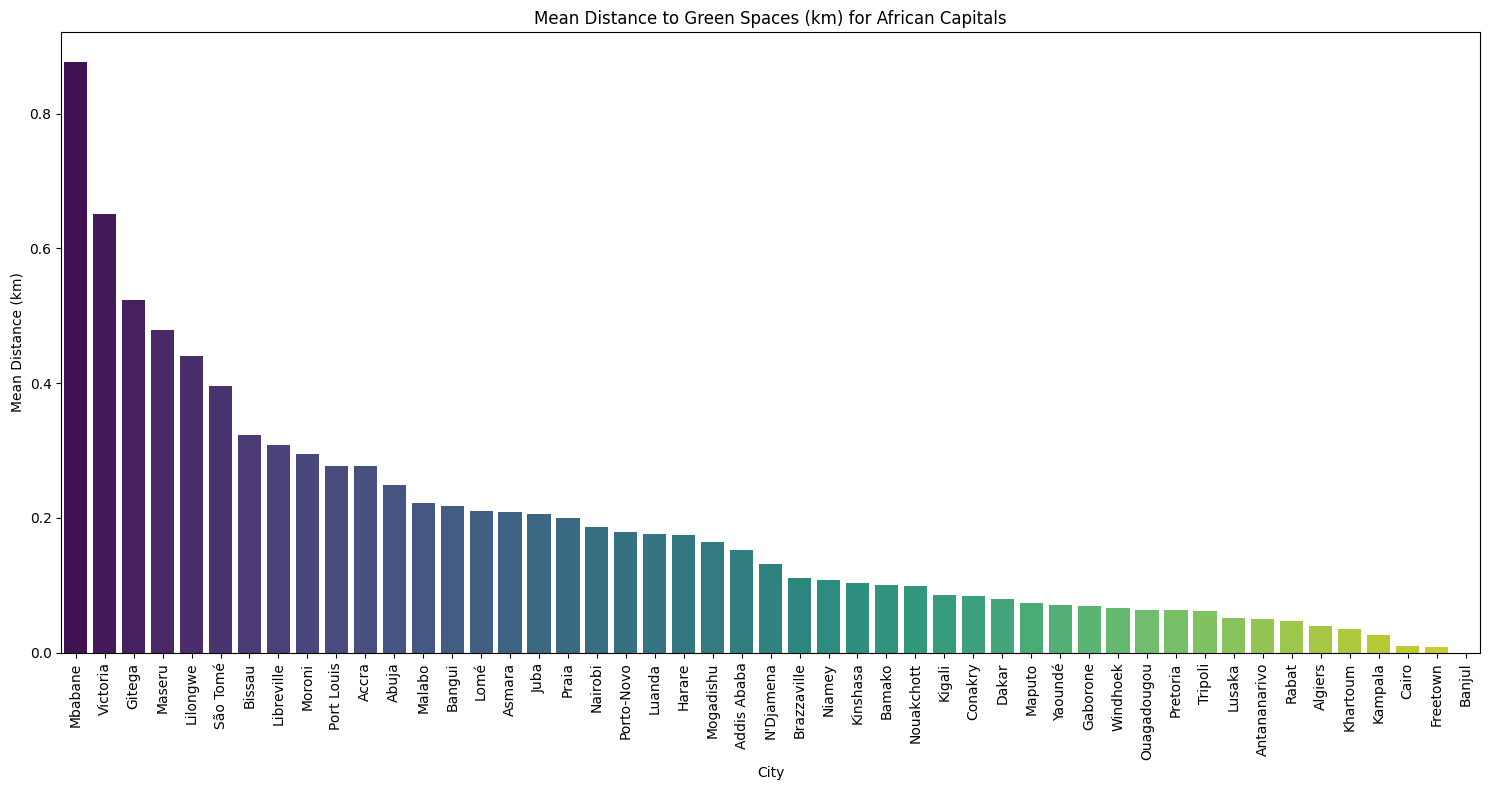

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by mean_distance_km for better visualization
results_df_sorted = results_df.sort_values(by='mean_distance_km', ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x='city', y='mean_distance_km', data=results_df_sorted, palette='viridis', hue='city', legend=False)
plt.title('Mean Distance to Green Spaces (km) for African Capitals')
plt.xlabel('City')
plt.ylabel('Mean Distance (km)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

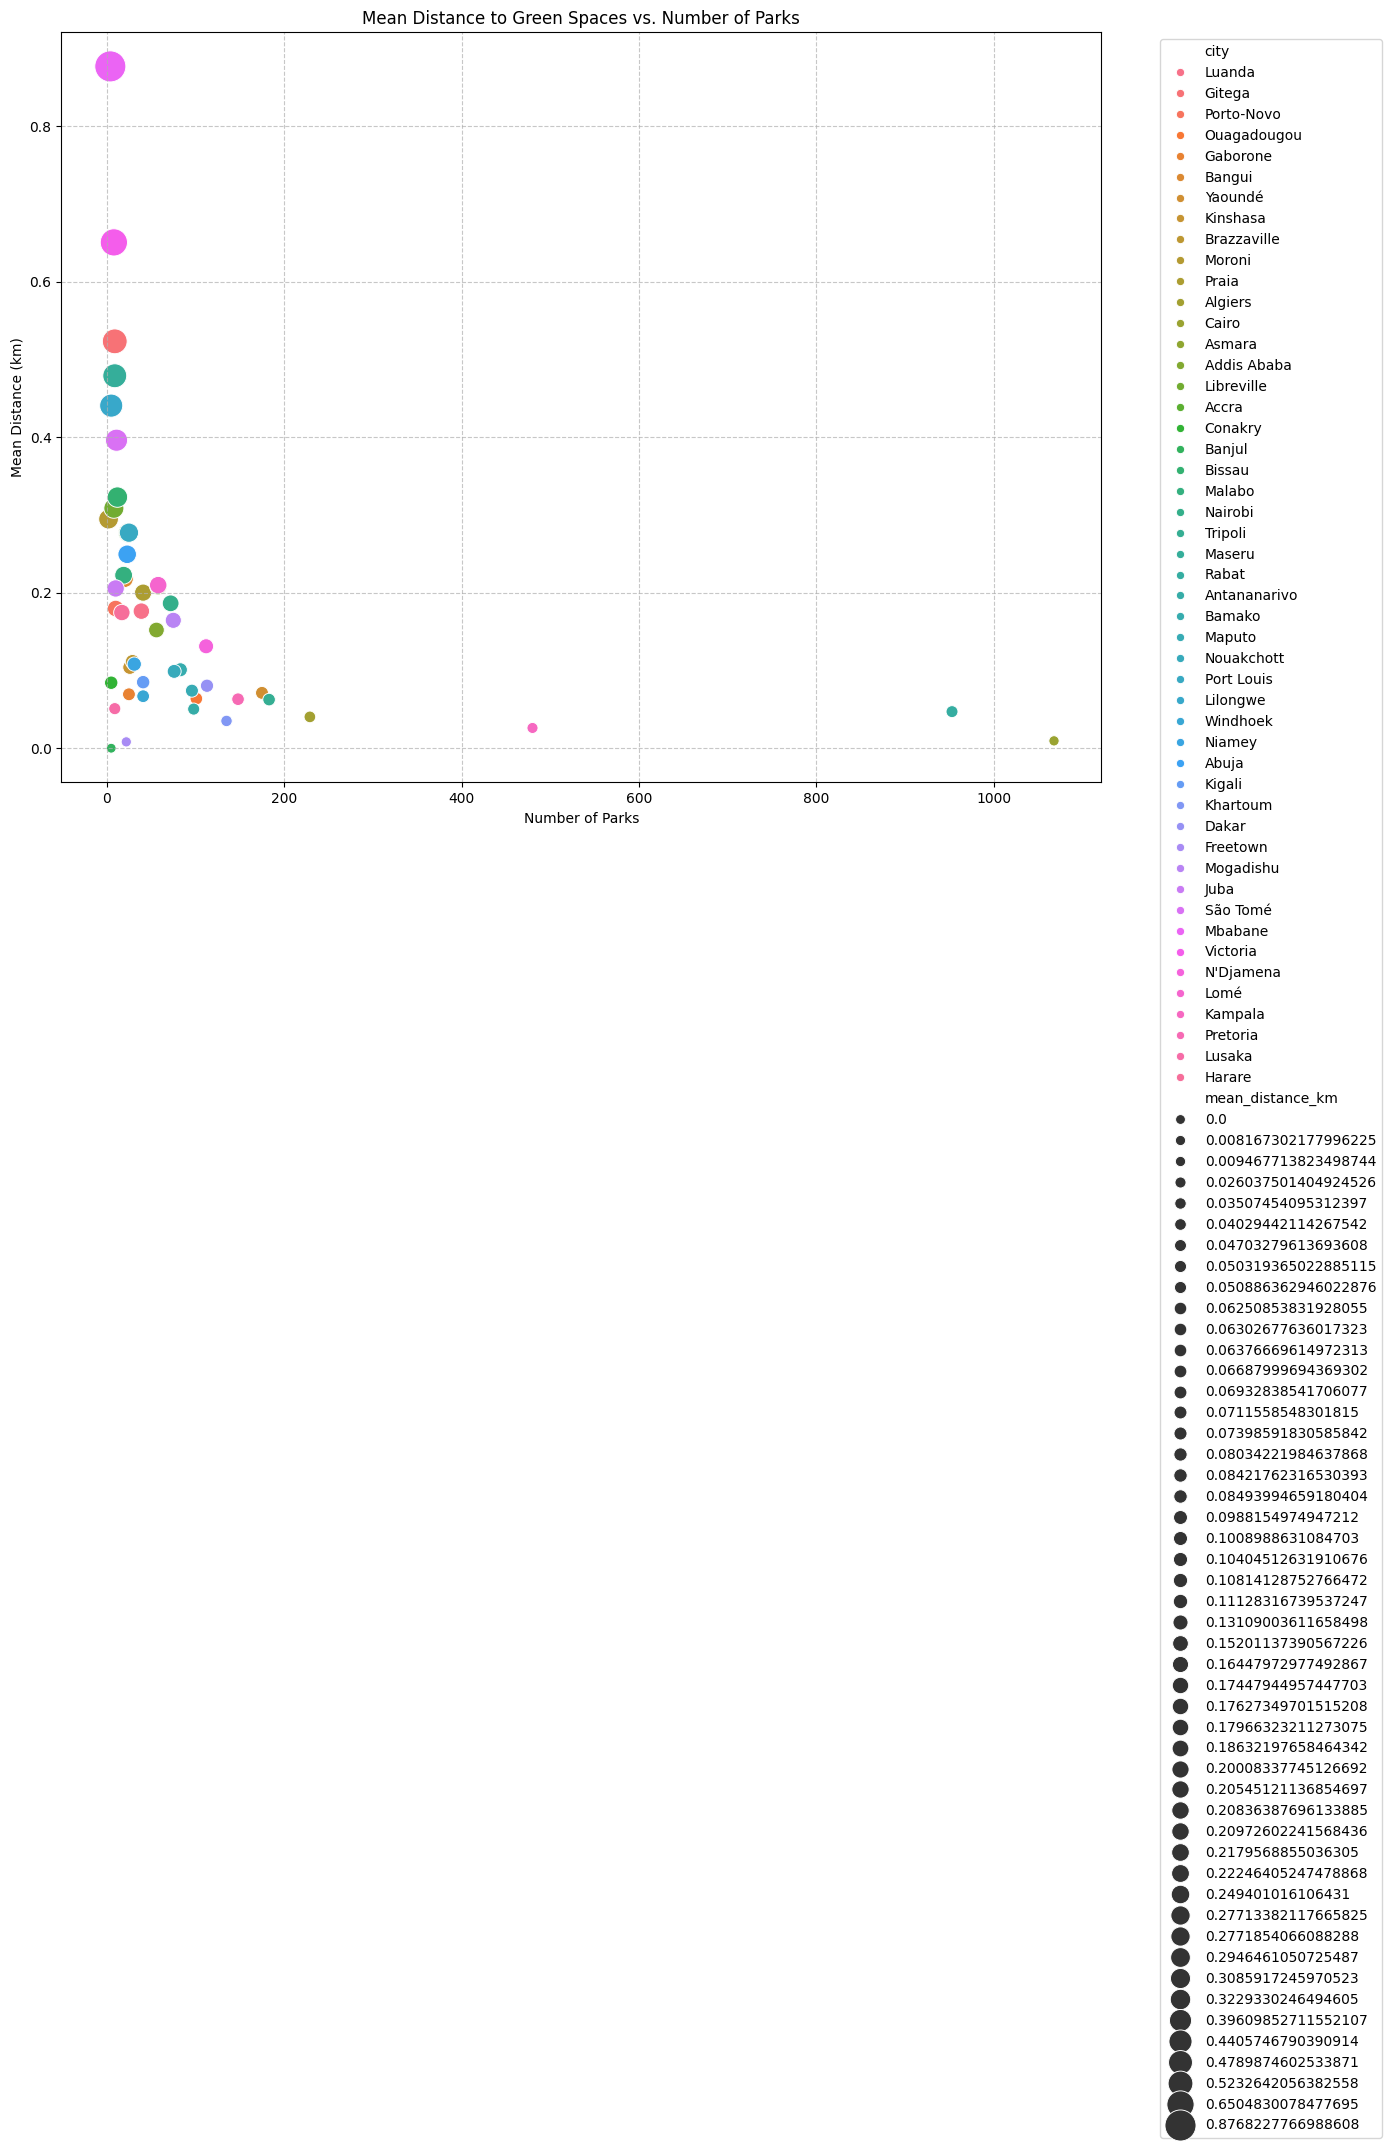

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10)) # Increased figure size
ax = sns.scatterplot(x='n_parks', y='mean_distance_km', data=results_df, hue='city', size='mean_distance_km', sizes=(50, 500), legend='full')
plt.title('Mean Distance to Green Spaces vs. Number of Parks')
plt.xlabel('Number of Parks')
plt.ylabel('Mean Distance (km)')
plt.grid(True, linestyle='--', alpha=0.7)

# Move the legend outside the plot area
if ax.legend_:
    ax.legend_.set_bbox_to_anchor((1.05, 1))
    ax.legend_.set_loc('upper left')

# Adjust subplot parameters for more space
plt.subplots_adjust(right=0.75, left=0.1, top=0.9, bottom=0.15)
plt.show()

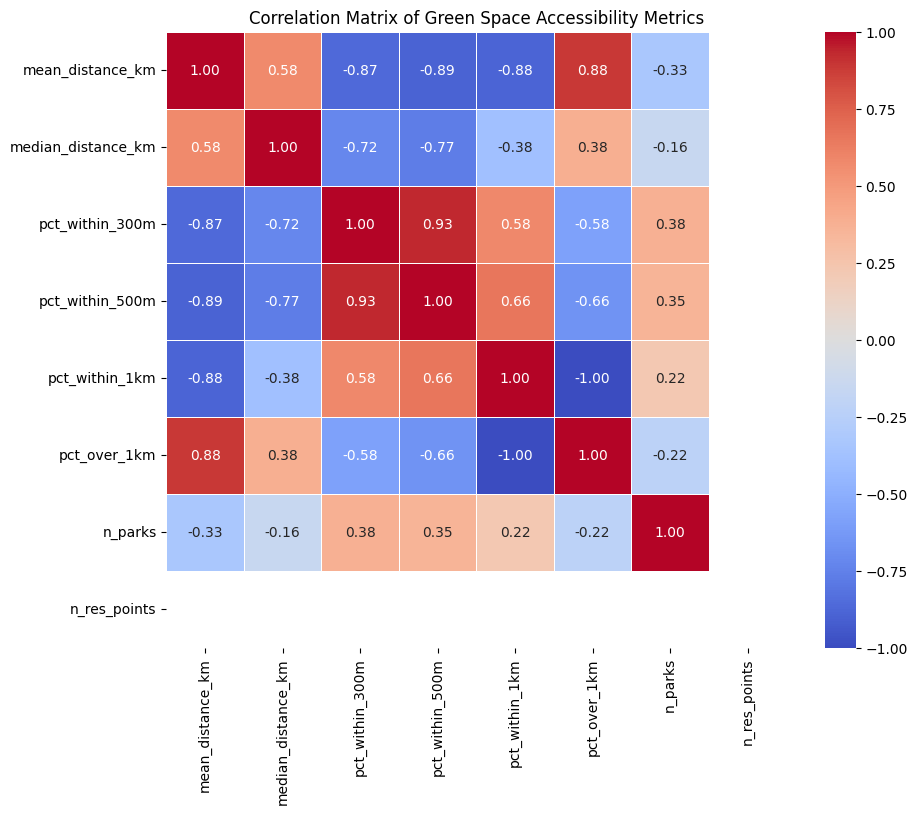

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the numerical columns
# Exclude 'city' and 'country' as they are categorical
correlation_matrix = results_df.drop(columns=['city', 'country']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Green Space Accessibility Metrics')
plt.show()

In [33]:
import folium
import geopandas as gpd
import pandas as pd
import requests
import zipfile
import io
import os
import tempfile # Import tempfile for creating temporary files

# Corrected URL for naturalearth_lowres data from a stable CDN
naturalearth_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

# Add a more comprehensive User-Agent header to mimic a web browser and avoid 406 errors
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.0.0 Safari/537.36'}

# Download the zip file
response = requests.get(naturalearth_url, headers=headers)
response.raise_for_status() # Raise an exception for HTTP errors

# Create a temporary directory to extract the shapefile
with tempfile.TemporaryDirectory() as tmpdir:
    zip_path = os.path.join(tmpdir, "ne_110m_admin_0_countries.zip")
    with open(zip_path, "wb") as f:
        f.write(response.content)

    # Extract the shapefile from the temporary zip archive
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(tmpdir)
        # Find the .shp file within the extracted files
        for root, _, files in os.walk(tmpdir):
            for file_name in files:
                if file_name.endswith('.shp'):
                    shp_path = os.path.join(root, file_name)
                    world = gpd.read_file(shp_path)
                    break
            else:
                continue
            break
        else:
            raise FileNotFoundError("Shapefile not found in the downloaded zip archive.")

# Filter for African countries using 'REGION_UN' as a fallback for 'continent'
africa_gdf = world[world['REGION_UN'] == 'Africa'].copy()

# Create a mapping for country names in results_df to match naturalearth_lowres names
country_name_map = {
    'DR Congo': 'Dem. Rep. Congo',
    'Ivory Coast': 'Côte d\'Ivoire',
    'Eswatini': 'eSwatini',
    'South Sudan': 'S. Sudan',
    'Western Sahara': 'W. Sahara'
    # Other country names like 'Congo', 'Tanzania', 'Sudan', etc., should match directly
}

# Apply the mapping to the 'country' column in results_df
# Create a new column for merging to avoid modifying the original 'country' column
results_df_for_merge = results_df.copy()
results_df_for_merge['country_for_merge'] = results_df_for_merge['country'].replace(country_name_map)

# Merge the African GeoDataFrame with the analysis results
# Using a left merge to keep all African countries, even those without data
africa_merged = africa_gdf.merge(
    results_df_for_merge,
    left_on='NAME', # Country name in naturalearth_lowres (corrected to 'NAME')
    right_on='country_for_merge',
    how='left'
)

# Create a Folium map centered roughly on Africa
m = folium.Map(location=[0, 20], zoom_start=2, tiles='CartoDB positron')

# Add the choropleth layer
choropleth = folium.Choropleth(
    geo_data=africa_merged,
    name='Mean Distance to Green Spaces',
    data=africa_merged,
    columns=['NAME', 'mean_distance_km'], # Column from africa_merged to color by (corrected to 'NAME')
    key_on='feature.properties.NAME',
    fill_color='YlGnBu', # Color scheme (Yellow-Green-Blue)
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Mean Distance to Green Spaces (km)',
    highlight=True,
    nan_fill_color='lightgray',
    nan_fill_opacity=0.5
).add_to(m)

# Add tooltips for interactivity
# This creates a GeoJson layer with tooltips that display relevant data on hover
folium.features.GeoJson(
    data=africa_merged.to_json(),
    name='Tooltip Layer',
    tooltip=folium.features.GeoJsonTooltip(
        fields=['NAME', 'city', 'mean_distance_km', 'n_parks'], # Corrected to 'NAME'
        aliases=['Country:', 'Capital:', 'Mean Dist. to Green Space (km):', 'Number of Parks:'],
        localize=True
    )
).add_to(m)

# Add layer control to toggle choropleth on/off (optional, but good for interactive maps)
folium.LayerControl().add_to(m)

# Display the map
m

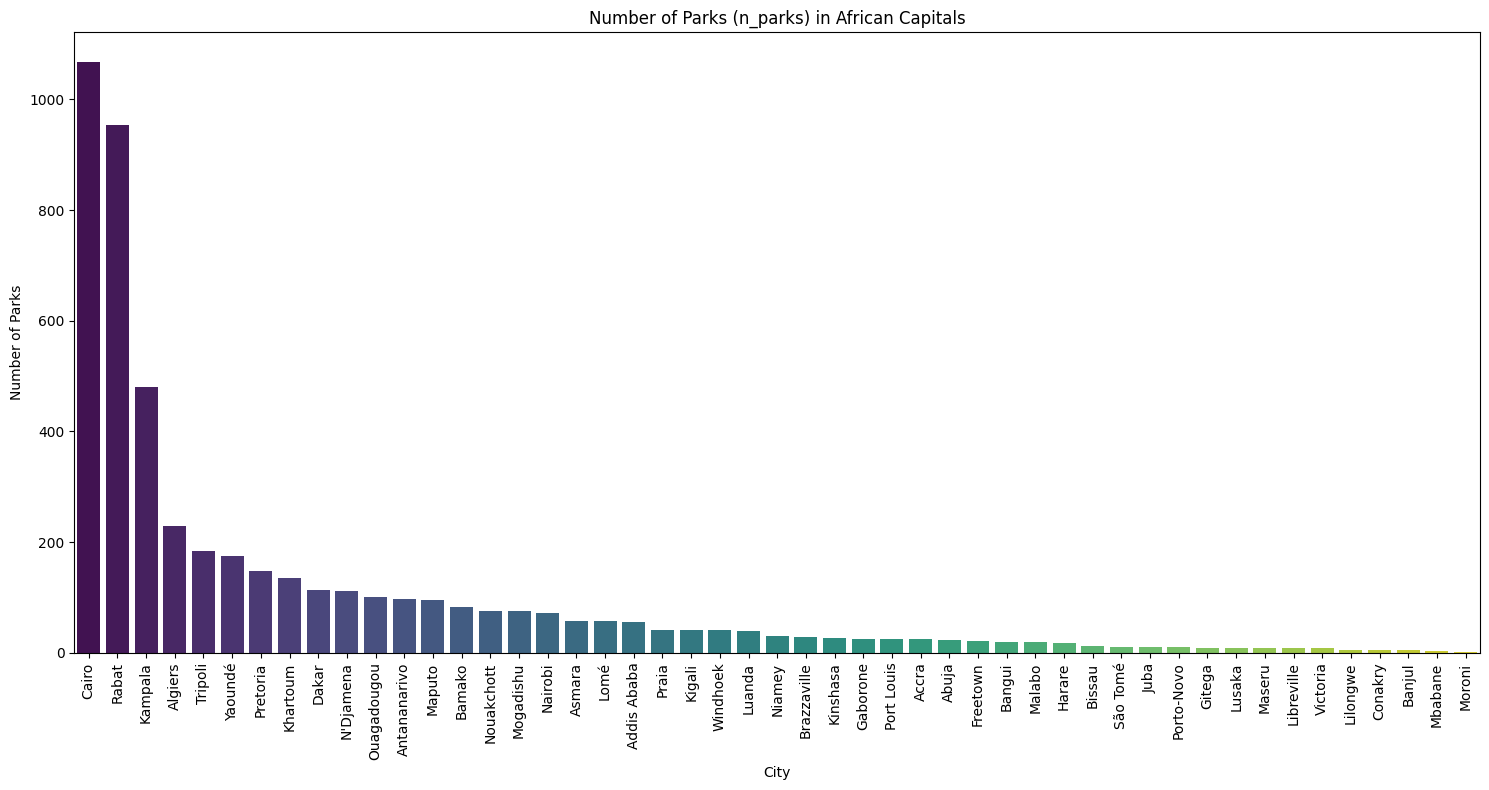

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by n_parks for better visualization
results_df_parks_sorted = results_df.sort_values(by='n_parks', ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x='city', y='n_parks', data=results_df_parks_sorted, palette='viridis', hue='city', legend=False)
plt.title('Number of Parks (n_parks) in African Capitals')
plt.xlabel('City')
plt.ylabel('Number of Parks')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [19]:
print("Cities with the highest mean distance to green spaces:")
display(results_df_sorted[['city', 'country', 'mean_distance_km']].head())

Cities with the highest mean distance to green spaces:


,city,country,mean_distance_km
41,Mbabane,Eswatini,0.876823
42,Victoria,Seychelles,0.650483
1,Gitega,Burundi,0.523264
23,Maseru,Lesotho,0.478987
30,Lilongwe,Malawi,0.440575
